# EVO-ECO Matrix: Cellular Plasticity as a Markov Decision Process
## Q-Learning Simulation — Cancer Cell Survival Strategy

**Core question:** At what metabolic cost does phenotypic plasticity become worse than proliferating and waiting for a random mutation?

## Biology Rules (MOCK — Replace with real rules from biology team)

Everything the biology students define goes here. Swap out the values below once they provide their rules. The engine below reads from `BioConfig` and does NOT need to change.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# BIOLOGY RULES — MOCK VALUES (replace with biology team input)
# ============================================================

class BioConfig:
    """
    All biology-defined parameters live here.
    Biology students: update ONLY this class.
    """

    # --- STATES ---
    # Each state represents a cell phenotype.
    # Format: {state_index: "label"}
    STATES = {
        0: "Differentiated",   # normal tumor cell
        1: "Stem-like",        # de-differentiated, therapy-resistant
        2: "Mutant-resistant",  # acquired genetic resistance (absorbing / terminal)
    }
    NUM_STATES = len(STATES)

    # --- ACTIONS ---
    # What the cell can "do" each generation.
    ACTIONS = {
        0: "Proliferate",      # divide in place, no phenotype change
        1: "Dedifferentiate",  # switch toward stem-like (plasticity)
        2: "Differentiate",    # switch toward differentiated
        3: "Wait",             # quiescent — do nothing
    }
    NUM_ACTIONS = len(ACTIONS)

    # --- THERAPY ENVIRONMENT ---
    THERAPY_KILL_PROB = {
        # Probability the therapy kills the cell in each state
        0: 0.60,   # differentiated: vulnerable
        1: 0.15,   # stem-like: resistant
        2: 0.05,   # mutant-resistant: nearly immune
    }

    # --- MUTATION ---
    # Probability of acquiring permanent genetic resistance per generation
    # (only while proliferating)
    MUTATION_PROB = 0.002

    # --- REWARD FUNCTION ---
    # Base survival reward each generation the cell stays alive
    SURVIVAL_REWARD = 1.0

    # Bonus for reaching permanent genetic resistance
    MUTATION_RESISTANCE_BONUS = 10.0

    # Metabolic cost of dedifferentiation (plasticity cost).
    # >>> THIS IS THE PARAMETER WE SWEEP <<<
    # Set a default here; the sweep loop will override it.
    PLASTICITY_COST = 0.3

    # Small cost for just proliferating (energy spent dividing)
    PROLIFERATION_COST = 0.05

    # Cost of doing nothing (quiescence penalty — not growing)
    QUIESCENCE_COST = 0.10

    # Cost of differentiating (small, going "with the grain")
    DIFFERENTIATION_COST = 0.02

    # --- TRANSITION LOGIC ---
    @staticmethod
    def transition(state, action, plasticity_cost_override=None):
        """
        Given current state and action, return (next_state, reward, done).
        `done` = True means the cell died or reached absorbing state.

        Biology students: modify this to match your model.
        """
        reward = BioConfig.SURVIVAL_REWARD
        plast_cost = plasticity_cost_override if plasticity_cost_override is not None else BioConfig.PLASTICITY_COST

        # --- If already mutant-resistant, stay there (absorbing state) ---
        if state == 2:
            return 2, reward + BioConfig.MUTATION_RESISTANCE_BONUS, False

        # --- Apply action effects ---
        next_state = state

        if action == 0:  # Proliferate
            reward -= BioConfig.PROLIFERATION_COST
            # Chance of gaining permanent resistance via mutation
            if np.random.rand() < BioConfig.MUTATION_PROB:
                return 2, reward + BioConfig.MUTATION_RESISTANCE_BONUS, False
            next_state = state  # stay in same phenotype

        elif action == 1:  # Dedifferentiate (plasticity)
            reward -= plast_cost
            # Move toward stem-like
            if state == 0:
                next_state = 1
            else:
                next_state = 1  # already stem-like, stay

        elif action == 2:  # Differentiate
            reward -= BioConfig.DIFFERENTIATION_COST
            if state == 1:
                next_state = 0
            else:
                next_state = 0  # already differentiated, stay

        elif action == 3:  # Wait (quiescence)
            reward -= BioConfig.QUIESCENCE_COST
            next_state = state

        # --- Therapy check: does the cell survive this generation? ---
        kill_prob = BioConfig.THERAPY_KILL_PROB[next_state]
        if np.random.rand() < kill_prob:
            return next_state, -1.0, True  # cell dies

        return next_state, reward, False

print("Biology rules loaded.")
print(f"  States:  {list(BioConfig.STATES.values())}")
print(f"  Actions: {list(BioConfig.ACTIONS.values())}")
print(f"  Default plasticity cost: {BioConfig.PLASTICITY_COST}")

## BioConfig Flowchart — State Transition Diagram

Visual map of the cancer cell MDP: states, actions, transition costs, therapy kill probabilities, and mutation path.

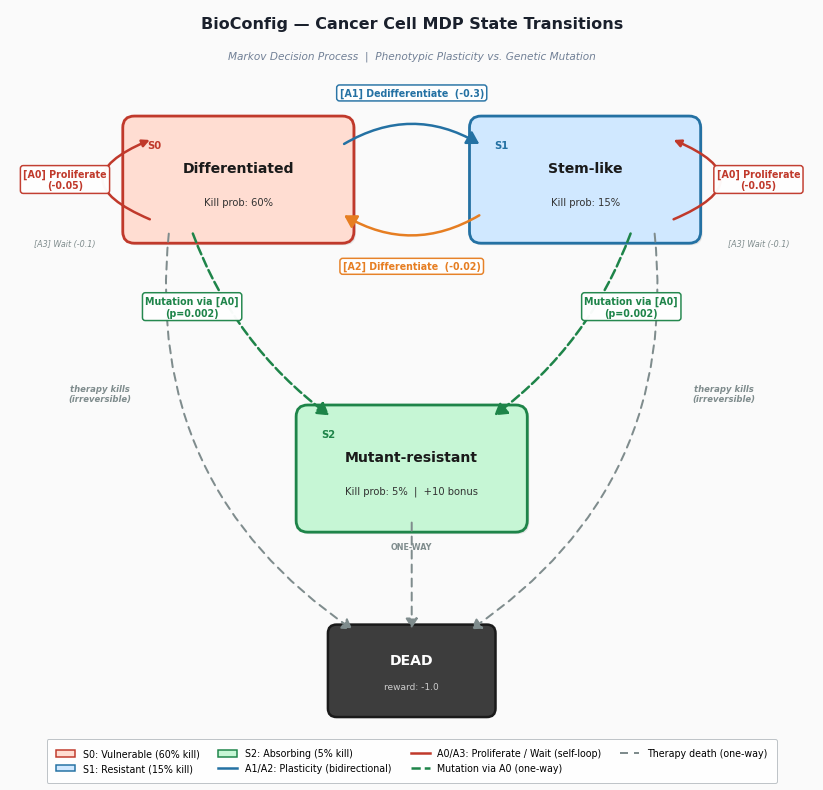

Flowchart saved to bioconfig_flowchart.png


In [58]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, ArrowStyle
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(14, 11))
ax.set_xlim(-1, 13)
ax.set_ylim(-0.5, 12.5)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

# ── Fonts ──
TITLE_FS = 16
STATE_FS = 14
SUB_FS = 10
ARROW_FS = 9.5
LEGEND_FS = 9.5
INDEX_FS = 10

# ── State positions ──
pos = {
    "diff":   (3.0, 9.5),
    "stem":   (9.0, 9.5),
    "mutant": (6.0, 4.5),
    "dead":   (6.0, 1.0),
}
BOX_W, BOX_H = 3.6, 1.8
SMALL_W, SMALL_H = 2.6, 1.3

# ── Draw state box with index label (no badge background) ──
def draw_state(ax, cx, cy, w, h, name, subtitle, color, border_color, index_label):
    box = FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                         boxstyle="round,pad=0.2", facecolor=color,
                         edgecolor=border_color, linewidth=2.8, zorder=3)
    box.set_path_effects([pe.withSimplePatchShadow(offset=(2, -2),
                         shadow_rgbFace='#BBBBBB', alpha=0.35)])
    ax.add_patch(box)
    # Index label (top-left corner, text only, no background)
    ax.text(cx - w/2 + 0.35, cy + h/2 - 0.3, index_label, ha='center', va='center',
            fontsize=INDEX_FS, fontweight='bold', color=border_color, zorder=6)
    # State name and subtitle
    ax.text(cx, cy + 0.2, name, ha='center', va='center', fontsize=STATE_FS,
            fontweight='bold', color='#1A1A1A', zorder=4)
    ax.text(cx, cy - 0.38, subtitle, ha='center', va='center', fontsize=SUB_FS,
            color='#333333', zorder=4)

# 3 main states
draw_state(ax, *pos["diff"], BOX_W, BOX_H,
           "Differentiated", f"Kill prob: {BioConfig.THERAPY_KILL_PROB[0]:.0%}",
           '#FFDDD2', '#C0392B', "S0")
draw_state(ax, *pos["stem"], BOX_W, BOX_H,
           "Stem-like", f"Kill prob: {BioConfig.THERAPY_KILL_PROB[1]:.0%}",
           '#D0E8FF', '#2471A3', "S1")
draw_state(ax, *pos["mutant"], BOX_W, BOX_H,
           "Mutant-resistant", f"Kill prob: {BioConfig.THERAPY_KILL_PROB[2]:.0%}  |  +{BioConfig.MUTATION_RESISTANCE_BONUS:.0f} bonus",
           '#C6F6D5', '#1E8449', "S2")

# Dead state
dead_box = FancyBboxPatch((pos["dead"][0] - SMALL_W/2, pos["dead"][1] - SMALL_H/2),
                          SMALL_W, SMALL_H,
                          boxstyle="round,pad=0.15", facecolor='#3D3D3D',
                          edgecolor='#1A1A1A', linewidth=2.5, zorder=3)
ax.add_patch(dead_box)
ax.text(pos["dead"][0], pos["dead"][1] + 0.18, "DEAD", ha='center', va='center',
        fontsize=STATE_FS, fontweight='bold', color='white', zorder=4)
ax.text(pos["dead"][0], pos["dead"][1] - 0.28, "reward: -1.0", ha='center', va='center',
        fontsize=SUB_FS - 1, color='#CCCCCC', zorder=4)

# ── Arrow helper with prominent arrowheads ──
def arrow(ax, start, end, label, color, rad=0.0, ls='-', lw=2.5, fs=ARROW_FS,
          lbl_offset=(0, 0), head_l=10, head_w=6):
    arr = FancyArrowPatch(start, end,
                          arrowstyle=ArrowStyle('-|>', head_length=head_l, head_width=head_w),
                          connectionstyle=f"arc3,rad={rad}",
                          color=color, linewidth=lw, linestyle=ls, zorder=6)
    ax.add_patch(arr)
    if label:
        mx = (start[0] + end[0]) / 2 + lbl_offset[0]
        my = (start[1] + end[1]) / 2 + lbl_offset[1]
        ax.text(mx, my, label, ha='center', va='center', fontsize=fs, color=color,
                fontweight='bold', zorder=7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=color, alpha=0.97, linewidth=1.5))

# ═══════════════════════════════════════════
# TRANSITIONS — action indices shown (A0-A3)
# ═══════════════════════════════════════════

# A1: Dedifferentiate: S0 → S1 (top arc)
arrow(ax, (4.8, 10.1), (7.2, 10.1),
      f"[A1] Dedifferentiate  (-{BioConfig.PLASTICITY_COST})",
      '#2471A3', rad=-0.3, lbl_offset=(0, 0.9))

# A2: Differentiate: S1 → S0 (bottom arc)
arrow(ax, (7.2, 8.9), (4.8, 8.9),
      f"[A2] Differentiate  (-{BioConfig.DIFFERENTIATION_COST})",
      '#E67E22', rad=-0.3, lbl_offset=(0, -0.9))

# A0: Proliferate self-loop: S0
ax.annotate("", xy=(1.5, 10.2), xytext=(1.5, 8.8),
            arrowprops=dict(arrowstyle='-|>', color='#C0392B', lw=2.5,
                            connectionstyle="arc3,rad=-1.2",
                            mutation_scale=15), zorder=6)
ax.text(0.0, 9.5, f"[A0] Proliferate\n(-{BioConfig.PROLIFERATION_COST})", ha='center', va='center',
        fontsize=ARROW_FS, color='#C0392B', fontweight='bold', zorder=7,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#C0392B', alpha=0.97, linewidth=1.5))
ax.text(0.0, 8.4, f"[A3] Wait (-{BioConfig.QUIESCENCE_COST})", ha='center', va='center',
        fontsize=8, color='#7F8C8D', style='italic', zorder=7)

# A0: Proliferate self-loop: S1
ax.annotate("", xy=(10.5, 10.2), xytext=(10.5, 8.8),
            arrowprops=dict(arrowstyle='-|>', color='#C0392B', lw=2.5,
                            connectionstyle="arc3,rad=1.2",
                            mutation_scale=15), zorder=6)
ax.text(12.0, 9.5, f"[A0] Proliferate\n(-{BioConfig.PROLIFERATION_COST})", ha='center', va='center',
        fontsize=ARROW_FS, color='#C0392B', fontweight='bold', zorder=7,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#C0392B', alpha=0.97, linewidth=1.5))
ax.text(12.0, 8.4, f"[A3] Wait (-{BioConfig.QUIESCENCE_COST})", ha='center', va='center',
        fontsize=8, color='#7F8C8D', style='italic', zorder=7)

# Mutation: S0 → S2 (dashed, via A0 Proliferate)
arrow(ax, (2.2, 8.6), (4.6, 5.4),
      f"Mutation via [A0]\n(p={BioConfig.MUTATION_PROB})",
      '#1E8449', rad=0.15, ls='--', lw=2.5, lbl_offset=(-1.2, 0.3))

# Mutation: S1 → S2 (dashed, via A0 Proliferate)
arrow(ax, (9.8, 8.6), (7.4, 5.4),
      f"Mutation via [A0]\n(p={BioConfig.MUTATION_PROB})",
      '#1E8449', rad=-0.15, ls='--', lw=2.5, lbl_offset=(1.2, 0.3))

# Therapy → Dead (all 3 states)
death_color = '#7F8C8D'
death_ls = (0, (4, 3))
arrow(ax, (1.8, 8.6), (5.0, 1.7),
      "", death_color, rad=0.3, ls=death_ls, lw=2.0, head_l=8, head_w=5)
arrow(ax, (10.2, 8.6), (7.0, 1.7),
      "", death_color, rad=-0.3, ls=death_ls, lw=2.0, head_l=8, head_w=5)
arrow(ax, (6.0, 3.6), (6.0, 1.7),
      "", death_color, rad=0.0, ls=death_ls, lw=2.0, head_l=8, head_w=5)

# Therapy kill labels
ax.text(0.6, 5.8, "therapy kills\n(irreversible)", ha='center', va='center',
        fontsize=8.5, color='#7F8C8D', style='italic', fontweight='semibold', zorder=7)
ax.text(11.4, 5.8, "therapy kills\n(irreversible)", ha='center', va='center',
        fontsize=8.5, color='#7F8C8D', style='italic', fontweight='semibold', zorder=7)
ax.text(6.0, 3.15, "ONE-WAY", ha='center', va='center',
        fontsize=8, color='#7F8C8D', fontweight='bold', zorder=7)

# ── Title ──
ax.text(6.0, 12.2, "BioConfig — Cancer Cell MDP State Transitions",
        ha='center', va='center', fontsize=TITLE_FS, fontweight='bold', color='#1A202C')
ax.text(6.0, 11.65, "Markov Decision Process  |  Phenotypic Plasticity vs. Genetic Mutation",
        ha='center', va='center', fontsize=10.5, color='#718096', style='italic')

# ── Legend (includes index key) ──
legend_elements = [
    mpatches.Patch(facecolor='#FFDDD2', edgecolor='#C0392B', lw=1.5, label='S0: Vulnerable (60% kill)'),
    mpatches.Patch(facecolor='#D0E8FF', edgecolor='#2471A3', lw=1.5, label='S1: Resistant (15% kill)'),
    mpatches.Patch(facecolor='#C6F6D5', edgecolor='#1E8449', lw=1.5, label='S2: Absorbing (5% kill)'),
    plt.Line2D([0], [0], color='#2471A3', lw=2.5, label='A1/A2: Plasticity (bidirectional)'),
    plt.Line2D([0], [0], color='#C0392B', lw=2.5, label='A0/A3: Proliferate / Wait (self-loop)'),
    plt.Line2D([0], [0], color='#1E8449', lw=2.5, ls='--', label='Mutation via A0 (one-way)'),
    plt.Line2D([0], [0], color='#7F8C8D', lw=2, ls=(0, (4, 3)), label='Therapy death (one-way)'),
]
ax.legend(handles=legend_elements, loc='lower center', fontsize=LEGEND_FS,
          framealpha=0.97, edgecolor='#BDC3C7', ncol=4, fancybox=True,
          bbox_to_anchor=(0.5, -0.04), borderpad=1.0)

plt.tight_layout()
plt.savefig("bioconfig_flowchart.png", dpi=200, bbox_inches="tight", facecolor='#FAFAFA')
plt.show()
print("Flowchart saved to bioconfig_flowchart.png")

## Q-Learning Engine

This cell is **generic**. It reads states/actions/transitions from `BioConfig` and does not need to change when biology rules are updated.

In [56]:
class QLearningEngine:
    """
    Tabular Q-learning agent.
    Reads state/action dimensions from BioConfig.
    """

    def __init__(self, lr=0.1, gamma=0.95, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.lr = lr                # learning rate
        self.gamma = gamma          # discount factor
        self.epsilon = epsilon      # exploration rate
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Q-table: rows = states, cols = actions
        self.q_table = np.zeros((BioConfig.NUM_STATES, BioConfig.NUM_ACTIONS))

    # Epsilon greedy so this parameter, I am randomly exploring at first
    # and down the line I become more greedy I pick the options that benefit me the most
    def choose_action(self, state):
        """Epsilon-greedy action selection."""
        if np.random.rand() < self.epsilon:
            return np.random.randint(BioConfig.NUM_ACTIONS)
        return int(np.argmax(self.q_table[state]))

    # Update the Q-Table, learning rate represents how much to react to new experiences
    def update(self, state, action, reward, next_state, done):
        """Standard Q-learning update rule."""
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.q_table[next_state])
        self.q_table[state, action] += self.lr * (target - self.q_table[state, action])

    # This method decays the epsilon to facilitate the behaviour of being random at first then more greedy
    def decay_epsilon(self):
        """Decay exploration rate after each episode."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    # This is a utility method used for reset
    def reset(self):
        """Reset Q-table and epsilon for a fresh training run."""
        self.q_table = np.zeros((BioConfig.NUM_STATES, BioConfig.NUM_ACTIONS))
        self.epsilon = 1.0


def print_qtable(agent: QLearningEngine):
    """Pretty-print the agent's Q-table with state/action names and best action markers."""
    col_width = 14
    header = f"{'State':<20} |"
    for a in range(BioConfig.NUM_ACTIONS):
        header += f" A{a}: {BioConfig.ACTIONS[a]:<{col_width - 4}} |"
    header += " Best Action"
    print("=" * len(header))
    print("  Q-Table")
    print("=" * len(header))
    print(header)
    print("-" * len(header))
    for s in range(BioConfig.NUM_STATES):
        best_a = int(np.argmax(agent.q_table[s]))
        row = f"{BioConfig.STATES[s]:<20} |"
        for a in range(BioConfig.NUM_ACTIONS):
            val = agent.q_table[s, a]
            marker = " *" if a == best_a else "  "
            row += f" {val:>+{col_width - 3}.2f}{marker} |"
        row += f" {BioConfig.ACTIONS[best_a]}"
        print(row)
    print("=" * len(header))
    print("  * = greedy-best action for that state")


# We run each episode for 1K steps, then we update the policy on the go
def run_episode(agent: QLearningEngine, max_steps=1000, plasticity_cost=None, start_state=0):
    """
    Simulate one cell lifetime (episode) under adaptive therapy.
    Returns total reward accumulated over the episode.
    """
    state = start_state
    total_reward = 0.0

    for step in range(max_steps):
        action = agent.choose_action(state)
        next_state, reward, done = BioConfig.transition(state, action, plasticity_cost_override=plasticity_cost) # it returns the states from the environment
        agent.update(state, action, reward, next_state, done)
        print_qtable(agent)
        total_reward += reward
        state = next_state
        if done:
            break

    return total_reward


def train_agent(plasticity_cost, num_episodes=500, max_steps=1000):
    """
    Train a Q-learning agent at a given plasticity cost.
    Returns the trained agent and list of episode rewards.
    """
    agent = QLearningEngine()
    episode_rewards = []

    for ep in range(num_episodes):
        reward = run_episode(agent, max_steps=max_steps, plasticity_cost=plasticity_cost)
        episode_rewards.append(reward)
        agent.decay_epsilon()

    return agent, episode_rewards

print("Q-Learning engine loaded.")

Q-Learning engine loaded.


## Interactive Step-Through Viewer

Walk through the Q-learning process one step at a time. This launches a **Tkinter window** with Prev/Next buttons that let you inspect each state transition, action chosen, reward received, and the evolving Q-table across multiple episodes.

- **State indicators** use the same color scheme as the flowchart above
- **Q-table** highlights the action chosen (yellow) and the greedy-best action (bold)
- **Episode summaries** appear between episodes showing outcome (died / survived / mutant)
- Use **Left/Right arrow keys** or the buttons to navigate
- Close the window to continue to the sweep section below

In [62]:
import tkinter as tk

# === CONFIGURATION ===
VIEWER_NUM_EPISODES = 500    # number of episodes to record
VIEWER_MAX_STEPS = 1000      # max steps per episode
VIEWER_PLASTICITY_COST = None  # None = use BioConfig default

# === COLORS (matching flowchart) ===
STATE_COLORS = {
    0: {"bg": "#FFDDD2", "border": "#C0392B", "label": "S0: Differentiated"},
    1: {"bg": "#D0E8FF", "border": "#2471A3", "label": "S1: Stem-like"},
    2: {"bg": "#C6F6D5", "border": "#1E8449", "label": "S2: Mutant-resistant"},
}

# === RECORD EPISODES (with calculation intermediates) ===
def record_episodes(num_episodes, max_steps, plasticity_cost):
    agent = QLearningEngine()
    timeline = []

    for ep in range(num_episodes):
        state = 0
        cumulative_reward = 0.0
        ep_steps = 0
        died = False

        for step in range(max_steps):
            # --- Action selection (inlined to capture metadata) ---
            greedy_action = int(np.argmax(agent.q_table[state]))
            greedy_q_value = float(agent.q_table[state, greedy_action])
            if np.random.rand() < agent.epsilon:
                action = np.random.randint(BioConfig.NUM_ACTIONS)
                was_random = True
            else:
                action = greedy_action
                was_random = False

            # --- Environment step ---
            next_state, reward, done = BioConfig.transition(
                state, action, plasticity_cost_override=plasticity_cost
            )

            # --- Q-value update (inlined to capture intermediates) ---
            old_q_value = float(agent.q_table[state, action])
            max_next_q = float(np.max(agent.q_table[next_state]))
            if done:
                target = reward
            else:
                target = reward + agent.gamma * max_next_q
            td_error = target - old_q_value
            agent.q_table[state, action] += agent.lr * td_error
            new_q_value = float(agent.q_table[state, action])

            cumulative_reward += reward
            ep_steps += 1

            timeline.append({
                "type": "step",
                "episode": ep,
                "step": step,
                "state": state,
                "state_name": BioConfig.STATES[state],
                "action": action,
                "action_name": BioConfig.ACTIONS[action],
                "reward": reward,
                "next_state": next_state,
                "next_state_name": BioConfig.STATES[next_state],
                "done": done,
                "cumulative_reward": cumulative_reward,
                "q_table_snapshot": agent.q_table.copy(),
                "epsilon": agent.epsilon,
                # --- Calculation intermediates ---
                "was_random": was_random,
                "greedy_action": greedy_action,
                "greedy_action_name": BioConfig.ACTIONS[greedy_action],
                "greedy_q_value": greedy_q_value,
                "old_q_value": old_q_value,
                "max_next_q": max_next_q,
                "target": target,
                "td_error": td_error,
                "new_q_value": new_q_value,
            })

            state = next_state
            if done:
                died = True
                break

        timeline.append({
            "type": "summary",
            "episode": ep,
            "total_steps": ep_steps,
            "total_reward": cumulative_reward,
            "final_state": state,
            "final_state_name": BioConfig.STATES[state],
            "died": died,
            "reached_mutant": (state == 2),
        })

        agent.decay_epsilon()

    return timeline, agent

# Record the episodes
timeline, _ = record_episodes(VIEWER_NUM_EPISODES, VIEWER_MAX_STEPS, VIEWER_PLASTICITY_COST)

# Count steps per episode for header display
ep_step_counts = {}
for entry in timeline:
    if entry["type"] == "summary":
        ep_step_counts[entry["episode"]] = entry["total_steps"]

print(f"Recorded {len(timeline)} timeline entries across {VIEWER_NUM_EPISODES} episodes.")
print("Launching viewer...")

# === TKINTER GUI ===
current_index = 0

root = tk.Tk()
root.title("Cancer Cell MDP — Episode Step-Through Viewer")
root.configure(bg="#FAFAFA")
root.geometry("750x1220")
root.resizable(False, False)

FONT_HEADER = ("Segoe UI", 14, "bold")
FONT_LABEL = ("Segoe UI", 10, "bold")
FONT_VALUE = ("Consolas", 10)
FONT_STATE = ("Segoe UI", 11)
FONT_QTABLE = ("Consolas", 9)
FONT_SUMMARY_TITLE = ("Segoe UI", 16, "bold")
FONT_SUMMARY = ("Consolas", 11)
FONT_HINT = ("Segoe UI", 9, "italic")
FONT_CALC = ("Consolas", 10)
FONT_CALC_BOLD = ("Consolas", 10, "bold")
BG = "#FAFAFA"

# --- Header frame ---
header_frame = tk.Frame(root, bg=BG, pady=10)
header_frame.pack(fill=tk.X, padx=15)

lbl_episode = tk.Label(header_frame, text="", font=FONT_HEADER, bg=BG)
lbl_episode.pack(side=tk.LEFT, padx=(0, 30))

lbl_step = tk.Label(header_frame, text="", font=FONT_HEADER, bg=BG)
lbl_step.pack(side=tk.LEFT, padx=(0, 30))

lbl_epsilon = tk.Label(header_frame, text="", font=("Segoe UI", 10), bg=BG, fg="#718096")
lbl_epsilon.pack(side=tk.RIGHT)

# --- Separator ---
tk.Frame(root, height=2, bg="#E2E8F0").pack(fill=tk.X, padx=15, pady=5)

# --- State indicator frame ---
state_indicator_frame = tk.Frame(root, bg=BG, pady=8)
state_indicator_frame.pack(fill=tk.X, padx=15)

state_labels = {}
for s_idx in range(BioConfig.NUM_STATES):
    colors = STATE_COLORS[s_idx]
    lbl = tk.Label(
        state_indicator_frame,
        text=colors["label"],
        font=FONT_STATE,
        bg=colors["bg"],
        fg="#1A1A1A",
        relief=tk.FLAT,
        borderwidth=3,
        padx=18, pady=10,
    )
    lbl.pack(side=tk.LEFT, padx=8, expand=True)
    state_labels[s_idx] = lbl

def highlight_state(active_idx):
    for s_idx, lbl in state_labels.items():
        colors = STATE_COLORS[s_idx]
        if s_idx == active_idx:
            lbl.config(relief=tk.RIDGE, borderwidth=4,
                       font=("Segoe UI", 11, "bold"),
                       highlightbackground=colors["border"], highlightthickness=3)
        else:
            lbl.config(relief=tk.FLAT, borderwidth=3,
                       font=("Segoe UI", 10),
                       highlightthickness=0)

# --- Separator ---
tk.Frame(root, height=2, bg="#E2E8F0").pack(fill=tk.X, padx=15, pady=5)

# --- Info frame (step details) ---
info_frame = tk.LabelFrame(root, text="Step Details", font=FONT_LABEL,
                           bg=BG, padx=12, pady=10)

info_fields = {}
field_defs = [
    ("State", "state_display"),
    ("Action", "action_display"),
    ("Reward", "reward_display"),
    ("Next State", "next_state_display"),
    ("Done", "done_display"),
    ("Cumul. Reward", "cumul_display"),
]
for row, (label_text, key) in enumerate(field_defs):
    tk.Label(info_frame, text=f"{label_text}:", font=FONT_LABEL,
             bg=BG, anchor=tk.W).grid(row=row, column=0, sticky=tk.W, padx=(0, 20), pady=3)
    val_lbl = tk.Label(info_frame, text="", font=FONT_VALUE, bg=BG, anchor=tk.W)
    val_lbl.grid(row=row, column=1, sticky=tk.W, pady=3)
    info_fields[key] = val_lbl

# --- Action Selection panel ---
action_sel_frame = tk.LabelFrame(root, text="Action Selection", font=FONT_LABEL,
                                  bg=BG, padx=12, pady=8)

lbl_action_mode = tk.Label(action_sel_frame, text="", font=FONT_CALC_BOLD, bg=BG, anchor=tk.W)
lbl_action_mode.pack(fill=tk.X, pady=(2, 1))

lbl_action_epsilon = tk.Label(action_sel_frame, text="", font=FONT_CALC, bg=BG,
                               anchor=tk.W, fg="#718096")
lbl_action_epsilon.pack(fill=tk.X, pady=1)

lbl_action_detail = tk.Label(action_sel_frame, text="", font=FONT_CALC, bg=BG, anchor=tk.W)
lbl_action_detail.pack(fill=tk.X, pady=1)

lbl_action_alt = tk.Label(action_sel_frame, text="", font=FONT_CALC, bg=BG,
                           anchor=tk.W, fg="#718096")
lbl_action_alt.pack(fill=tk.X, pady=(1, 2))

# --- Q-Value Update Calculation panel ---
qcalc_frame = tk.LabelFrame(root, text="Q-Value Update Calculation", font=FONT_LABEL,
                              bg=BG, padx=12, pady=8)

lbl_calc_old_q = tk.Label(qcalc_frame, text="", font=FONT_CALC, bg=BG, anchor=tk.W)
lbl_calc_old_q.pack(fill=tk.X, pady=(2, 1))

lbl_calc_target = tk.Label(qcalc_frame, text="", font=FONT_CALC, bg=BG, anchor=tk.W)
lbl_calc_target.pack(fill=tk.X, pady=1)

lbl_calc_td = tk.Label(qcalc_frame, text="", font=FONT_CALC, bg=BG, anchor=tk.W)
lbl_calc_td.pack(fill=tk.X, pady=1)

lbl_calc_new_q = tk.Label(qcalc_frame, text="", font=FONT_CALC_BOLD, bg=BG, anchor=tk.W)
lbl_calc_new_q.pack(fill=tk.X, pady=(1, 2))

# --- Q-Table frame ---
qtable_frame = tk.LabelFrame(root, text="Q-Table (after this step's update)",
                             font=FONT_LABEL, bg=BG, padx=10, pady=8)

# Build Q-table grid headers
qtable_cells = {}
# Corner cell
tk.Label(qtable_frame, text="", font=FONT_QTABLE, bg=BG, width=16).grid(row=0, column=0)
# Action headers
for a in range(BioConfig.NUM_ACTIONS):
    tk.Label(qtable_frame, text=f"A{a}: {BioConfig.ACTIONS[a][:5]}",
             font=("Consolas", 9, "bold"), bg="#E8E8E8",
             width=10, relief=tk.GROOVE, padx=3, pady=2
             ).grid(row=0, column=a + 1, padx=1, pady=1)
# State headers + value cells
for s in range(BioConfig.NUM_STATES):
    tk.Label(qtable_frame, text=f"S{s}: {BioConfig.STATES[s][:12]}",
             font=("Consolas", 9, "bold"), bg="#E8E8E8",
             width=16, anchor=tk.W, relief=tk.GROOVE, padx=3, pady=2
             ).grid(row=s + 1, column=0, padx=1, pady=1)
    for a in range(BioConfig.NUM_ACTIONS):
        cell = tk.Label(qtable_frame, text="0.00", font=FONT_QTABLE,
                        bg="white", width=10, relief=tk.SUNKEN, padx=3, pady=2)
        cell.grid(row=s + 1, column=a + 1, padx=1, pady=1)
        qtable_cells[(s, a)] = cell

def update_qtable(q_snapshot, active_state, active_action):
    for s in range(BioConfig.NUM_STATES):
        best_a = int(np.argmax(q_snapshot[s]))
        for a in range(BioConfig.NUM_ACTIONS):
            val = q_snapshot[s, a]
            cell = qtable_cells[(s, a)]
            is_chosen = (s == active_state and a == active_action)
            is_best = (a == best_a)
            bg_color = "#FFFFAA" if is_chosen else "white"
            weight = "bold" if is_best else "normal"
            cell.config(text=f"{val:+.2f}", bg=bg_color,
                        font=("Consolas", 9, weight))

# --- State Transition Diagram ---
diagram_frame = tk.LabelFrame(root, text="State Transition Diagram",
                               font=FONT_LABEL, bg=BG, padx=5, pady=5)

diagram_canvas = tk.Canvas(diagram_frame, width=700, height=280,
                            bg="#FAFAFA", highlightthickness=0)
diagram_canvas.pack()

# Box center positions for icon placement
STATE_BOX_CENTERS = {
    0: (175, 55),
    1: (525, 55),
    2: (350, 155),
    "dead": (350, 245),
}

# Rounded rectangle helper
def _round_rect(c, x1, y1, x2, y2, r=10, **kw):
    pts = [x1+r,y1, x2-r,y1, x2,y1, x2,y1+r,
           x2,y2-r, x2,y2, x2-r,y2, x1+r,y2,
           x1,y2, x1,y2-r, x1,y1+r, x1,y1]
    return c.create_polygon(pts, smooth=True, **kw)

# -- Draw state boxes --
_boxes = [
    (0, 95, 25, 255, 85, "S0: Differentiated", "60% kill", "#FFDDD2", "#C0392B"),
    (1, 445, 25, 605, 85, "S1: Stem-like", "15% kill", "#D0E8FF", "#2471A3"),
    (2, 270, 125, 430, 185, "S2: Mutant-resistant", "5% kill", "#C6F6D5", "#1E8449"),
]
for s, x1, y1, x2, y2, label, sub, fill, border in _boxes:
    _round_rect(diagram_canvas, x1, y1, x2, y2, r=12,
                fill=fill, outline=border, width=2)
    cx, cy = STATE_BOX_CENTERS[s]
    diagram_canvas.create_text(cx, cy - 8, text=label,
        font=("Segoe UI", 9, "bold"), fill="#1A1A1A")
    diagram_canvas.create_text(cx, cy + 10, text=sub,
        font=("Segoe UI", 8), fill="#555555")

# DEAD box
_round_rect(diagram_canvas, 290, 225, 410, 265, r=8,
            fill="#3D3D3D", outline="#1A1A1A", width=2)
diagram_canvas.create_text(350, 240, text="DEAD",
    font=("Segoe UI", 9, "bold"), fill="white")
diagram_canvas.create_text(350, 255, text="reward: -1",
    font=("Segoe UI", 7), fill="#AAAAAA")

# -- Draw arrows with probabilities/costs --

# A1: Dedifferentiate S0 -> S1 (deterministic action — agent chooses via Q-table)
diagram_canvas.create_line(255, 42, 445, 42,
    fill="#2471A3", width=2, arrow=tk.LAST, arrowshape=(10, 12, 5))
plast_cost = VIEWER_PLASTICITY_COST if VIEWER_PLASTICITY_COST is not None else BioConfig.PLASTICITY_COST
diagram_canvas.create_text(350, 28, text=f"A1: Dediff. (cost: -{plast_cost})",
    font=("Segoe UI", 7, "bold"), fill="#2471A3")

# A2: Differentiate S1 -> S0 (deterministic action — agent chooses via Q-table)
diagram_canvas.create_line(445, 68, 255, 68,
    fill="#E67E22", width=2, arrow=tk.LAST, arrowshape=(10, 12, 5))
diagram_canvas.create_text(350, 82, text=f"A2: Diff. (cost: -{BioConfig.DIFFERENTIATION_COST})",
    font=("Segoe UI", 7, "bold"), fill="#E67E22")

# Mutation S0 -> S2 (dashed, via A0 Proliferate, p=MUTATION_PROB)
diagram_canvas.create_line(175, 85, 310, 125,
    fill="#1E8449", width=1.5, arrow=tk.LAST, arrowshape=(8, 10, 4), dash=(6, 4))
diagram_canvas.create_text(218, 113, text=f"Mutate p={BioConfig.MUTATION_PROB:.1%}",
    font=("Segoe UI", 7, "bold"), fill="#1E8449")

# Mutation S1 -> S2 (dashed, via A0 Proliferate, p=MUTATION_PROB)
diagram_canvas.create_line(525, 85, 390, 125,
    fill="#1E8449", width=1.5, arrow=tk.LAST, arrowshape=(8, 10, 4), dash=(6, 4))
diagram_canvas.create_text(482, 113, text=f"Mutate p={BioConfig.MUTATION_PROB:.1%}",
    font=("Segoe UI", 7, "bold"), fill="#1E8449")

# Therapy arrows to DEAD (dotted gray) with kill probabilities
# S0 -> DEAD (60% kill)
diagram_canvas.create_line(135, 85, 350, 225,
    fill="#7F8C8D", width=1.5, arrow=tk.LAST, arrowshape=(6, 8, 3), dash=(3, 3))
diagram_canvas.create_text(225, 160, text=f"p={BioConfig.THERAPY_KILL_PROB[0]:.0%}",
    font=("Segoe UI", 7, "bold"), fill="#7F8C8D")

# S1 -> DEAD (15% kill)
diagram_canvas.create_line(565, 85, 350, 225,
    fill="#7F8C8D", width=1.5, arrow=tk.LAST, arrowshape=(6, 8, 3), dash=(3, 3))
diagram_canvas.create_text(475, 160, text=f"p={BioConfig.THERAPY_KILL_PROB[1]:.0%}",
    font=("Segoe UI", 7, "bold"), fill="#7F8C8D")

# S2 -> DEAD (5% kill)
diagram_canvas.create_line(350, 185, 350, 225,
    fill="#7F8C8D", width=1.5, arrow=tk.LAST, arrowshape=(6, 8, 3), dash=(3, 3))
diagram_canvas.create_text(370, 205, text=f"p={BioConfig.THERAPY_KILL_PROB[2]:.0%}",
    font=("Segoe UI", 7, "bold"), fill="#7F8C8D")

# Self-loop labels with costs
diagram_canvas.create_text(175, 12, text=f"\u21BB A0 (-{BioConfig.PROLIFERATION_COST}) / A3 (-{BioConfig.QUIESCENCE_COST})",
    font=("Segoe UI", 7), fill="#C0392B")
diagram_canvas.create_text(525, 12, text=f"\u21BB A0 (-{BioConfig.PROLIFERATION_COST}) / A3 (-{BioConfig.QUIESCENCE_COST})",
    font=("Segoe UI", 7), fill="#2471A3")

# Mini legend
diagram_canvas.create_oval(15, 260, 25, 270, fill="#E74C3C",
    outline="#922B21", width=1)
diagram_canvas.create_text(30, 265, text="= current state",
    font=("Segoe UI", 7), fill="#666666", anchor=tk.W)
diagram_canvas.create_oval(130, 260, 140, 270, fill="",
    outline="#E74C3C", width=1, dash=(3, 2))
diagram_canvas.create_text(145, 265, text="= next state",
    font=("Segoe UI", 7), fill="#666666", anchor=tk.W)

def update_cell_icons(state, next_state, done):
    """Update cell agent icon positions on the diagram."""
    diagram_canvas.delete("cell_icon")

    CELL_R = 11
    OFFSET = 15

    solid_cx, solid_cy = STATE_BOX_CENTERS[state]

    if done:
        ghost_cx, ghost_cy = STATE_BOX_CENTERS["dead"]
    else:
        ghost_cx, ghost_cy = STATE_BOX_CENTERS[next_state]

    same_box = (state == next_state) and not done
    if same_box:
        solid_cx -= OFFSET
        ghost_cx += OFFSET

    # Solid icon (current state)
    diagram_canvas.create_oval(
        solid_cx - CELL_R, solid_cy - CELL_R,
        solid_cx + CELL_R, solid_cy + CELL_R,
        fill="#E74C3C", outline="#922B21", width=2, tags="cell_icon")
    diagram_canvas.create_text(
        solid_cx, solid_cy, text="C", fill="white",
        font=("Segoe UI", 9, "bold"), tags="cell_icon")

    # Dotted icon (next state)
    diagram_canvas.create_oval(
        ghost_cx - CELL_R, ghost_cy - CELL_R,
        ghost_cx + CELL_R, ghost_cy + CELL_R,
        fill="", outline="#E74C3C", width=2, dash=(4, 3), tags="cell_icon")
    diagram_canvas.create_text(
        ghost_cx, ghost_cy, text="C", fill="#E74C3C",
        font=("Segoe UI", 9, "bold"), tags="cell_icon")

    # Arrow between icons if in different boxes
    if not same_box:
        dx = ghost_cx - solid_cx
        dy = ghost_cy - solid_cy
        dist = (dx**2 + dy**2) ** 0.5
        if dist > 0:
            sx = solid_cx + (dx / dist) * (CELL_R + 3)
            sy = solid_cy + (dy / dist) * (CELL_R + 3)
            ex = ghost_cx - (dx / dist) * (CELL_R + 3)
            ey = ghost_cy - (dy / dist) * (CELL_R + 3)
            diagram_canvas.create_line(
                sx, sy, ex, ey,
                fill="#E74C3C", width=2, arrow=tk.LAST,
                arrowshape=(8, 10, 4), dash=(5, 3), tags="cell_icon")

# --- Summary frame (hidden by default) ---
summary_frame = tk.Frame(root, bg=BG, pady=20)

lbl_summary_title = tk.Label(summary_frame, text="", font=FONT_SUMMARY_TITLE, bg=BG)
lbl_summary_title.pack(pady=(0, 15))

lbl_summary_details = tk.Label(summary_frame, text="", font=FONT_SUMMARY,
                               bg=BG, justify=tk.LEFT)
lbl_summary_details.pack(pady=5)

lbl_summary_outcome = tk.Label(summary_frame, text="", font=("Segoe UI", 13, "bold"), bg=BG)
lbl_summary_outcome.pack(pady=12)

lbl_summary_hint = tk.Label(summary_frame, text="", font=FONT_HINT, bg=BG, fg="#718096")
lbl_summary_hint.pack(pady=(10, 0))

# --- Bottom separator and buttons ---
bottom_separator = tk.Frame(root, height=2, bg="#E2E8F0")
bottom_separator.pack(fill=tk.X, padx=15, pady=5)

button_frame = tk.Frame(root, bg=BG, pady=10)
button_frame.pack(fill=tk.X, padx=15)

btn_prev = tk.Button(button_frame, text="<< Prev", font=("Segoe UI", 11, "bold"),
                     bg="#E2E8F0", activebackground="#CBD5E0",
                     width=12, pady=5)
btn_prev.pack(side=tk.LEFT, padx=(30, 0))

btn_next = tk.Button(button_frame, text="Next >>", font=("Segoe UI", 11, "bold"),
                     bg="#E2E8F0", activebackground="#CBD5E0",
                     width=12, pady=5)
btn_next.pack(side=tk.RIGHT, padx=(0, 30))

lbl_global = tk.Label(button_frame, text="", font=("Segoe UI", 9), bg=BG, fg="#718096")
lbl_global.pack()

# === DISPLAY LOGIC ===
def display_current():
    global current_index
    entry = timeline[current_index]

    if entry["type"] == "summary":
        # Hide step views, show summary
        info_frame.pack_forget()
        action_sel_frame.pack_forget()
        qcalc_frame.pack_forget()
        qtable_frame.pack_forget()
        diagram_frame.pack_forget()
        summary_frame.pack(fill=tk.X, padx=15, pady=5)

        # Re-pack bottom elements
        bottom_separator.pack_forget()
        button_frame.pack_forget()
        bottom_separator.pack(fill=tk.X, padx=15, pady=5)
        button_frame.pack(fill=tk.X, padx=15)

        ep = entry["episode"]
        lbl_episode.config(text=f"Episode {ep + 1} / {VIEWER_NUM_EPISODES}")
        lbl_step.config(text="Summary")
        lbl_epsilon.config(text="")

        highlight_state(entry["final_state"])

        lbl_summary_title.config(text=f"=== Episode {ep + 1} Summary ===")
        details = (
            f"Total Steps:    {entry['total_steps']}\n"
            f"Total Reward:   {entry['total_reward']:+.2f}\n"
            f"Final State:    S{entry['final_state']} {entry['final_state_name']}"
        )
        lbl_summary_details.config(text=details)

        if entry["died"]:
            lbl_summary_outcome.config(text="OUTCOME: Cell DIED (therapy)", fg="#C0392B")
        elif entry["reached_mutant"]:
            lbl_summary_outcome.config(text="OUTCOME: Mutant Resistant (absorbing)", fg="#1E8449")
        else:
            lbl_summary_outcome.config(text="OUTCOME: SURVIVED (max steps)", fg="#2471A3")

        if current_index < len(timeline) - 1:
            lbl_summary_hint.config(text=f"Press Next to begin Episode {ep + 2}")
        else:
            lbl_summary_hint.config(text="End of recorded episodes.")

    else:
        # Hide summary, show step views in order
        summary_frame.pack_forget()
        info_frame.pack(fill=tk.X, padx=15, pady=5)
        action_sel_frame.pack(fill=tk.X, padx=15, pady=5)
        qcalc_frame.pack(fill=tk.X, padx=15, pady=5)
        qtable_frame.pack(fill=tk.X, padx=15, pady=5)
        diagram_frame.pack(fill=tk.X, padx=15, pady=5)

        # Re-pack bottom elements
        bottom_separator.pack_forget()
        button_frame.pack_forget()
        bottom_separator.pack(fill=tk.X, padx=15, pady=5)
        button_frame.pack(fill=tk.X, padx=15)

        ep = entry["episode"]
        total_steps = ep_step_counts.get(ep, "?")
        lbl_episode.config(text=f"Episode {ep + 1} / {VIEWER_NUM_EPISODES}")
        lbl_step.config(text=f"Step {entry['step'] + 1} / {total_steps}")
        lbl_epsilon.config(text=f"Epsilon: {entry['epsilon']:.3f}")

        highlight_state(entry["state"])

        info_fields["state_display"].config(
            text=f"S{entry['state']}  {entry['state_name']}")
        info_fields["action_display"].config(
            text=f"A{entry['action']}  {entry['action_name']}")

        r = entry["reward"]
        color = "#1E8449" if r > 0 else "#C0392B" if r < 0 else "#1A1A1A"
        info_fields["reward_display"].config(text=f"{r:+.3f}", fg=color)

        info_fields["next_state_display"].config(
            text=f"S{entry['next_state']}  {entry['next_state_name']}")

        done_text = "YES — cell died" if entry["done"] else "No"
        done_color = "#C0392B" if entry["done"] else "#1A1A1A"
        info_fields["done_display"].config(text=done_text, fg=done_color)

        info_fields["cumul_display"].config(text=f"{entry['cumulative_reward']:+.2f}")

        update_qtable(entry["q_table_snapshot"], entry["state"], entry["action"])

        # --- Populate Action Selection panel ---
        if entry["was_random"]:
            lbl_action_mode.config(
                text="Mode: EXPLORATION (random)",
                fg="#E67E22"
            )
            lbl_action_epsilon.config(
                text=f"Epsilon: {entry['epsilon']:.4f}  (rand < epsilon => random action)"
            )
            lbl_action_detail.config(
                text=f"Random pick:  A{entry['action']} {entry['action_name']}"
            )
            lbl_action_alt.config(
                text=f"Greedy would have been:  A{entry['greedy_action']} "
                     f"{entry['greedy_action_name']}  "
                     f"(Q={entry['greedy_q_value']:+.2f})"
            )
        else:
            lbl_action_mode.config(
                text="Mode: EXPLOITATION (greedy)",
                fg="#1E8449"
            )
            lbl_action_epsilon.config(
                text=f"Epsilon: {entry['epsilon']:.4f}  (rand >= epsilon => greedy action)"
            )
            lbl_action_detail.config(
                text=f"Best Q-value action:  A{entry['action']} {entry['action_name']}  "
                     f"(Q={entry['old_q_value']:+.2f})"
            )
            lbl_action_alt.config(text="")

        # --- Populate Q-Value Update Calculation panel ---
        s = entry["state"]
        a = entry["action"]

        lbl_calc_old_q.config(
            text=f"Old Q[S{s}, A{a}] = {entry['old_q_value']:+.4f}"
        )

        if entry["done"]:
            lbl_calc_target.config(
                text=f"Target = reward = {entry['reward']:+.4f}    (done=True, no future)"
            )
        else:
            lbl_calc_target.config(
                text=f"Target = reward + \u03b3 \u00d7 max(Q[S{entry['next_state']}]) = "
                     f"{entry['reward']:+.2f} + 0.95 \u00d7 {entry['max_next_q']:+.2f} = "
                     f"{entry['target']:+.4f}"
            )

        lbl_calc_td.config(
            text=f"TD Error = Target - Old Q = "
                 f"{entry['target']:+.4f} - ({entry['old_q_value']:+.4f}) = "
                 f"{entry['td_error']:+.4f}"
        )

        lbl_calc_new_q.config(
            text=f"New Q[S{s}, A{a}] = {entry['old_q_value']:+.4f} + "
                 f"0.1 \u00d7 {entry['td_error']:+.4f} = {entry['new_q_value']:+.4f}"
        )

        # --- Update cell icons on diagram ---
        update_cell_icons(entry["state"], entry["next_state"], entry["done"])

    # Global position + button states
    lbl_global.config(text=f"Timeline: {current_index + 1} / {len(timeline)}")
    btn_prev.config(state=tk.NORMAL if current_index > 0 else tk.DISABLED)
    btn_next.config(state=tk.NORMAL if current_index < len(timeline) - 1 else tk.DISABLED)

def go_next():
    global current_index
    if current_index < len(timeline) - 1:
        current_index += 1
        display_current()

def go_prev():
    global current_index
    if current_index > 0:
        current_index -= 1
        display_current()

btn_prev.config(command=go_prev)
btn_next.config(command=go_next)
root.bind("<Left>", lambda e: go_prev())
root.bind("<Right>", lambda e: go_next())

# Initial display
display_current()

# Run the event loop (blocks until window is closed)
root.mainloop()
print("Viewer closed.")

Recorded 3948 timeline entries across 500 episodes.
Launching viewer...
Viewer closed.


## Sweep: Find the Tipping Point

Trains a separate agent for each plasticity cost value. For each, we record:
1. **Average survival reward** (higher = better strategy)
2. **Preferred policy** (does the agent prefer plasticity or proliferate-and-wait?)

In [ ]:
# === SWEEP PARAMETERS ===
COST_RANGE = np.linspace(0.0, 2.0, 30)  # plasticity costs to test
NUM_EPISODES = 500                        # training episodes per cost level
MAX_STEPS = 1000                          # max generations per episode (as required)
NUM_EVAL_EPISODES = 200                   # episodes to evaluate the trained policy

np.random.seed(42)

results = {
    "costs": [],
    "avg_rewards": [],
    "plasticity_fraction": [],   # fraction of time agent chooses dedifferentiate
    "proliferate_fraction": [],  # fraction of time agent chooses proliferate
    "avg_survival_steps": [],
}

for cost in COST_RANGE:
    # Train
    agent, train_rewards = train_agent(plasticity_cost=cost, num_episodes=NUM_EPISODES, max_steps=MAX_STEPS)

    # Evaluate trained policy (greedy, no exploration)
    agent.epsilon = 0.0
    eval_rewards = []
    action_counts = np.zeros(BioConfig.NUM_ACTIONS)
    survival_steps_list = []

    for _ in range(NUM_EVAL_EPISODES):
        state = 0
        ep_reward = 0.0
        for step in range(MAX_STEPS):
            action = agent.choose_action(state)
            action_counts[action] += 1
            next_state, reward, done = BioConfig.transition(state, action, plasticity_cost_override=cost)
            ep_reward += reward
            state = next_state
            if done:
                survival_steps_list.append(step)
                break
        else:
            survival_steps_list.append(MAX_STEPS)
        eval_rewards.append(ep_reward)

    total_actions = action_counts.sum()
    results["costs"].append(cost)
    results["avg_rewards"].append(np.mean(eval_rewards))
    results["plasticity_fraction"].append(action_counts[1] / total_actions)  # dedifferentiate
    results["proliferate_fraction"].append(action_counts[0] / total_actions)  # proliferate
    results["avg_survival_steps"].append(np.mean(survival_steps_list))

    print(f"Cost={cost:.2f} | Avg Reward={np.mean(eval_rewards):.1f} | "
          f"Plasticity={action_counts[1]/total_actions:.1%} | "
          f"Proliferate={action_counts[0]/total_actions:.1%} | "
          f"Avg Survival={np.mean(survival_steps_list):.0f} steps")

print("\nSweep complete.")

## Tipping-Point Visualization

Three plots:
1. **Strategy preference** — plasticity vs. proliferation fraction across cost levels
2. **Average survival reward** — overall fitness vs. plasticity cost
3. **Average survival duration** — how long the cell lives

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

costs = results["costs"]

# --- Plot 1: Strategy preference ---
ax1 = axes[0]
ax1.plot(costs, results["plasticity_fraction"], "b-o", markersize=4, label="Plasticity (Dedifferentiate)")
ax1.plot(costs, results["proliferate_fraction"], "r-s", markersize=4, label="Proliferate & Wait")
ax1.set_xlabel("Plasticity Cost (metabolic units)", fontsize=12)
ax1.set_ylabel("Fraction of Actions Chosen", fontsize=12)
ax1.set_title("Strategy Preference vs. Plasticity Cost", fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Find and mark the crossover (tipping point)
plast = np.array(results["plasticity_fraction"])
prolif = np.array(results["proliferate_fraction"])
crossover_idx = np.where(np.diff(np.sign(plast - prolif)))[0]
if len(crossover_idx) > 0:
    ci = crossover_idx[0]
    tipping_cost = np.interp(0, [plast[ci] - prolif[ci], plast[ci+1] - prolif[ci+1]], [costs[ci], costs[ci+1]])
    ax1.axvline(x=tipping_cost, color="green", linestyle="--", linewidth=2, label=f"Tipping point ≈ {tipping_cost:.2f}")
    ax1.legend()
    print(f">>> TIPPING POINT: Plasticity fails at cost ≈ {tipping_cost:.2f} metabolic units <<<")
else:
    print("No clear crossover detected — try widening the cost range.")

# --- Plot 2: Average reward ---
ax2 = axes[1]
ax2.plot(costs, results["avg_rewards"], "g-^", markersize=4)
ax2.set_xlabel("Plasticity Cost (metabolic units)", fontsize=12)
ax2.set_ylabel("Average Cumulative Reward", fontsize=12)
ax2.set_title("Cell Fitness vs. Plasticity Cost", fontsize=13)
ax2.grid(True, alpha=0.3)
if len(crossover_idx) > 0:
    ax2.axvline(x=tipping_cost, color="green", linestyle="--", linewidth=2, alpha=0.7)

# --- Plot 3: Survival duration ---
ax3 = axes[2]
ax3.plot(costs, results["avg_survival_steps"], "m-D", markersize=4)
ax3.set_xlabel("Plasticity Cost (metabolic units)", fontsize=12)
ax3.set_ylabel("Avg Survival (generations)", fontsize=12)
ax3.set_title("Survival Duration vs. Plasticity Cost", fontsize=13)
ax3.grid(True, alpha=0.3)
if len(crossover_idx) > 0:
    ax3.axvline(x=tipping_cost, color="green", linestyle="--", linewidth=2, alpha=0.7)

plt.tight_layout()
plt.savefig("tipping_point.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graph saved to tipping_point.png")

## Q-Table Analysis

Shows the learned policy at low vs. high plasticity cost to illustrate the strategy shift.

In [ ]:
def show_policy(plasticity_cost):
    """Train an agent and display its learned Q-table and preferred actions."""
    agent, _ = train_agent(plasticity_cost=plasticity_cost, num_episodes=500, max_steps=1000)
    print(f"\n{'='*60}")
    print(f"  Learned Policy at Plasticity Cost = {plasticity_cost:.2f}")
    print(f"{'='*60}")
    print(f"\n{'State':<20} | {'Best Action':<18} | Q-values")
    print("-" * 70)
    for s in range(BioConfig.NUM_STATES):
        best_a = int(np.argmax(agent.q_table[s]))
        q_vals = ", ".join(f"{q:.2f}" for q in agent.q_table[s])
        print(f"{BioConfig.STATES[s]:<20} | {BioConfig.ACTIONS[best_a]:<18} | [{q_vals}]")

# Compare low cost (plasticity should win) vs high cost (proliferate should win)
show_policy(0.1)
show_policy(1.5)